In [ ]:
0. Install and Import Dependencies



4. Use Easy OCR To reas text
5. render result 


In [1]:
pip install easyocr

  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
  Using cached opencv_python_headless-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached scikit_image-0.26.0-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached ninja-1.13.0-py3-none-win_amd64.whl.metadata (5.1 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
Using cached easyocr-1.7.2-py3-none-any.whl (2.9 MB)
Using cached ninja-1.13.0-py3-none-win_amd64.whl (309 kB)
Using cached opencv_python_headless-4.13.0.90-cp37-abi3-win_amd64.whl (40.1 MB)
Using cached scikit_image-0.26.0-cp313-cp313-win_amd64.whl (11.9 MB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)

   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   -------------------------

In [2]:
pip install imutils

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25889 sha256=553a486a3eea3ddea8aa5291ef74f027b28155e1efd0d69d87ff9b1fd16f60de
  Stored in directory: c:\users\r6190\appdata\local\pip\cache\wheels\69\2c\66\f966db29490794305257ac3abfe71d4f963f5fc75ba0eb8eb7
Successfully built imutils
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.


In [8]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import imutils
import easyocr

1. Read in Image,Grayscale and Blur

In [21]:
import os
print(os.getcwd())  # shows current working directory
print(os.path.exists(r"ml_projects\images_for_ALPD\image1.jpg"))

c:\Users\r6190\OneDrive\Desktop\PYTHON\ml_projects
False


In [44]:
img = cv2.imread(r"C:\Users\r6190\Downloads\image2.jpg")
if img is None:
    raise FileNotFoundError("Image not found or unable to load")


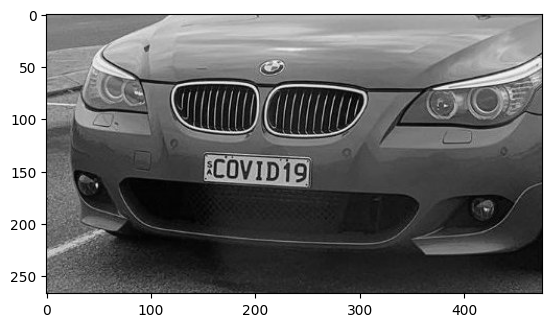

In [45]:


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

2. Apply filter and find edges for localization

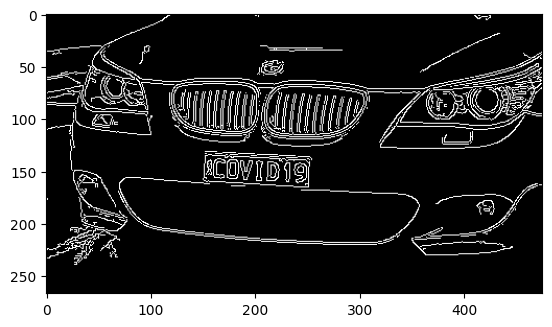

In [46]:
bfilter = cv2.bilateralFilter(gray,11,17,17)#Noise Reduction
edged = cv2.Canny(bfilter,30,200) # edge detection
plt.imshow(cv2.cvtColor(edged,cv2.COLOR_BGR2RGB))


3. Find Contours and Apply Mask

In [ ]:
keypoints = cv2.findContours(edged.copy(),cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours,key = cv2.contourArea,reverse = True)[:10]

In [48]:
location = None
for contour in contours:
    approx = cv2.approxPolyDP(contour,10,True)
    if len(approx) == 4:
        location = approx
        break

In [49]:
location

array([[[152, 136]],

       [[248, 139]],

       [[251, 164]],

       [[153, 160]]], dtype=int32)

In [50]:
mask = np.zeros(gray.shape,np.uint8)
new_image = cv2.drawContours(mask,[location],0,255,-1)
new_image = cv2.bitwise_and(img,img,mask =mask)

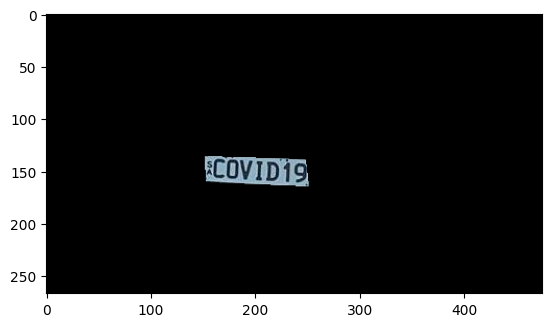

In [51]:
plt.imshow(cv2.cvtColor(new_image,cv2.COLOR_BGR2RGB))

In [52]:
(x,y) = np.where(mask ==255)
(x1,y1) = (np.min(x),np.min(y))
(x2,y2) = (np.max(x), np.max(y))
cropped_image = gray[x1:x2+1, y1:y2+1]

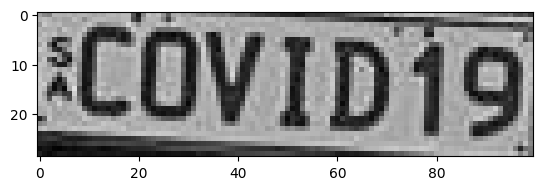

In [53]:
plt.imshow(cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB))

4. Use Easy OCR to read text

In [54]:
reader = easyocr.Reader(['en'])
result = reader.readtext(cropped_image)
result

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\r6190\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[([[0, 0], [100, 0], [100, 29], [0, 29]],
  'ICOVIDT9',
  np.float64(0.5275640804797114))]

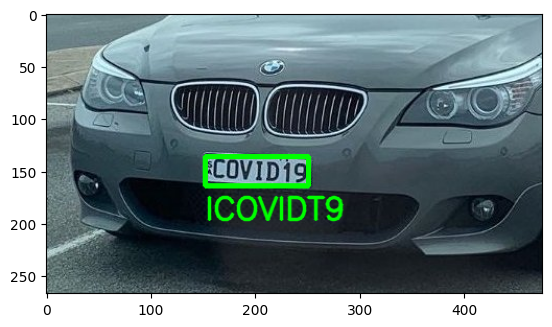

In [55]:
text = result[0][-2]
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(
    img,
    text=text,
    org=(approx[0][0][0], approx[0][0][1] + 60),
    fontFace=font,
    fontScale=1,
    color=(0, 255, 0),
    thickness=2,
    lineType=cv2.LINE_AA
)

res =cv2.rectangle(img, tuple(approx[0][0]),tuple(approx[2][0]),(0,255,0) ,3)
plt.imshow(cv2.cvtColor(res,cv2.COLOR_BGR2RGB))

In [66]:


def detect_number_plate(image_path):
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError("Image not found or unable to load")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Noise reduction and edge detection
    bfilter = cv2.bilateralFilter(gray, 11, 17, 17)
    edged = cv2.Canny(bfilter, 30, 200)

    # Find contours
    keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(keypoints)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    location = None
    for contour in contours:
        approx = cv2.approxPolyDP(contour, 10, True)
        if len(approx) == 4:
            location = approx
            break

    if location is None:
        return None

    # Mask and crop plate
    mask = np.zeros(gray.shape, np.uint8)
    cv2.drawContours(mask, [location], 0, 255, -1)

    (x, y) = np.where(mask == 255)
    (x1, y1) = (np.min(x), np.min(y))
    (x2, y2) = (np.max(x), np.max(y))

    cropped_image = gray[x1:x2+1, y1:y2+1]

    # OCR
    reader = easyocr.Reader(['en'], gpu=False)
    result = reader.readtext(cropped_image)

    if len(result) == 0:
        return None

    text = result[0][-2]

    # Draw rectangle around plate
    cv2.rectangle(
        img,
        tuple(location[0][0]),
        tuple(location[2][0]),
        (0, 255, 0),
        3
    )

    # Put text at right-most corner
    font = cv2.FONT_HERSHEY_SIMPLEX
    h, w, _ = img.shape

    cv2.putText(
        img,
        text=text,
        org= (approx[0][0][0], approx[0][0][1] + 60)  , # right-most corner
        fontFace=font,
        fontScale=1,
        color=(0, 255, 0),
        thickness=2,
        lineType=cv2.LINE_AA
    )

    # Show final output
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return text


Using CPU. Note: This module is much faster with a GPU.


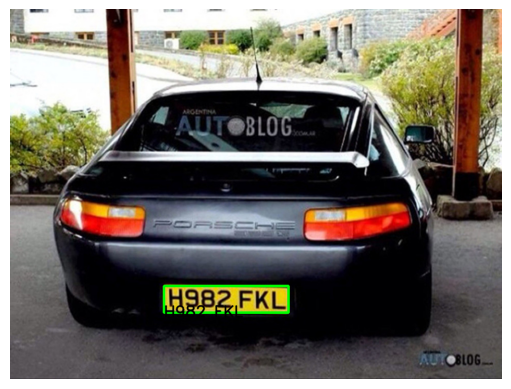

Detected Number Plate: H982 FKL


In [65]:
plate_number = detect_number_plate(r"C:\Users\r6190\Downloads\image4.jpg")
print("Detected Number Plate:", plate_number)
